# Lesson 3 — Data Preparation & Baseline Modeling

In Lessons 1 and 2 we covered Business Understanding, Data Collection, and EDA. Today we move into the next two CRISP-DM phases:

**Data Preparation → Modeling**

We will build two baseline models from scratch:

| | Dataset | Task | Model Type |
|---|---|---|---|
| **Part 1** | Titanic (Kaggle) | Predict who survives | Logistic Regression |
| **Part 2** | House Prices (Kaggle) | Predict sale price | Linear Regression |

The goal is **not** to squeeze out maximum accuracy. The goal is to build a clean, interpretable baseline — and understand why these two models were the right choices for each problem.

---
## Setup

```bash
pip install pandas numpy matplotlib seaborn scikit-learn kaggle
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_auc_score, roc_curve,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

---
# How Do You Pick a Model?

Before writing a single line of sklearn, you need to answer one question:

> **What kind of output am I trying to predict?**

| Output Type | Example | Model Family |
|---|---|---|
| A category / class | Survived: Yes or No | **Classification** |
| A continuous number | House price: $245,000 | **Regression** |

This is the most important decision in ML. Get it wrong and no amount of tuning will fix it.

```
                    ┌─────────────────────────────────┐
                    │     What is my target?          │
                    └────────────┬────────────────────┘
                                 │
               ┌─────────────────┴──────────────────┐
               │                                    │
        A Category/Label                    A Number
        (Yes/No, A/B/C)                  (price, score)
               │                                    │
        CLASSIFICATION                       REGRESSION
      Logistic Regression               Linear Regression
      Decision Tree                     Decision Tree
      Random Forest                     Random Forest
      XGBoost                           XGBoost
      Neural Network                    Neural Network
```

Notice: many model families appear in both columns. The *architecture* adapts — the *question you ask* determines which side you are on.

---
# Part 1 — Logistic Regression on Titanic
## Classification: Predicting a Category

**Business question:** Given what we know about a passenger, did they survive?

**Target:** `Survived` — either `0` (did not survive) or `1` (survived)

This is a **binary classification** problem. The output is a class, not a number.

### Why Logistic Regression?
- Simple, fast, and interpretable — you can read the coefficients and understand *why* it makes a prediction
- Strong baseline: if a complex model can't beat logistic regression, it isn't learning anything real
- Output is a **probability** between 0 and 1, which gets converted to a class label

```
  Features ──► [Logistic Regression] ──► P(Survived) = 0.83 ──► Predict: 1 (Survived)
                                                              └──► Predict: 0 (Did not survive)
                                                                   (if P < 0.5)
```

## 1.1 — Data Preparation

Raw data is never model-ready. Here is the preparation checklist we identified during EDA:

| Problem | Column(s) | Fix |
|---|---|---|
| ~77% missing | Cabin | Drop the column |
| ~20% missing | Age | Impute with median |
| ~0.2% missing | Embarked | Impute with mode |
| Categorical strings | Sex, Embarked | Encode to numbers |
| Non-informative | PassengerId, Name, Ticket | Drop |
| Skewed distribution | Fare | Log transform |
| Feature opportunity | SibSp + Parch | Engineer FamilySize, IsAlone |

In [2]:
df = pd.read_csv("Titanic-Dataset.csv")
print("Shape:", df.shape)
df.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# ── Step 1: Drop non-informative columns ──────────────────────────────────────
df_clean = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

# ── Step 2: Impute missing values ─────────────────────────────────────────────
df_clean["Age"] = df_clean["Age"].fillna(df_clean["Age"].median())
df_clean["Embarked"] = df_clean["Embarked"].fillna(df_clean["Embarked"].mode()[0])

# ── Step 3: Feature engineering ───────────────────────────────────────────────
df_clean["FamilySize"] = df_clean["SibSp"] + df_clean["Parch"] + 1
df_clean["IsAlone"] = (df_clean["FamilySize"] == 1).astype(int)
df_clean["LogFare"] = np.log1p(df_clean["Fare"])

# ── Step 4: Encode categorical columns ────────────────────────────────────────
df_clean["Sex"] = df_clean["Sex"].map({"male": 0, "female": 1})
df_clean["Embarked"] = df_clean["Embarked"].map({"S": 0, "C": 1, "Q": 2})

print("Missing values remaining:", df_clean.isnull().sum().sum())
print("Shape after prep:", df_clean.shape)
df_clean.head()

Missing values remaining: 0
Shape after prep: (891, 11)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,LogFare
0,0,3,0,22.0,1,0,7.2500,0,2,0,2.110213
1,1,1,1,38.0,1,0,71.2833,1,2,0,4.280593
2,1,3,1,26.0,0,0,7.9250,0,1,1,2.188856
3,1,1,1,35.0,1,0,53.1000,0,2,0,3.990834
4,0,3,0,35.0,0,0,8.0500,0,1,1,2.202765


### Activity 1 — Why These Choices?

Discuss with your group and answer in the cell below:

1. We dropped `Cabin` but imputed `Age`. What is the rule of thumb for **when to drop vs. impute** a column with missing values?
2. We used **median** for Age, not mean. Why? (Hint: look at the Age boxplot from Lesson 2)
3. We used `log1p(Fare)` instead of `Fare`. What problem does this solve and why does it matter for a linear model?
4. We mapped `Sex` to `{male: 0, female: 1}`. Could we have used any other numbers? Would the model care?

In [ ]:
# Your answers here (as comments or print statements)

# 1. Drop vs Impute rule of thumb:

# 2. Median vs Mean:

# 3. Log transform:

# 4. Encoding values:

## 1.2 — Train / Test Split

We never evaluate a model on the data it trained on. That would be like grading a student on the exact homework they already did — it tells you nothing about whether they actually learned.

```
  Full Dataset (891 rows)
  ├── Training Set (80%) ──► Model learns patterns here
  └── Test Set    (20%) ──► We evaluate honestly here (model never sees this during training)
```

In [4]:
FEATURES = ["Pclass", "Sex", "Age", "SibSp", "Parch", "LogFare", "Embarked", "FamilySize", "IsAlone"]
TARGET = "Survived"

X = df_clean[FEATURES]
y = df_clean[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set:  {X_train.shape[0]} rows")
print(f"Test set:      {X_test.shape[0]} rows")
print(f"\nSurvival rate in train: {y_train.mean():.3f}")
print(f"Survival rate in test:  {y_test.mean():.3f}")

Training set:  712 rows
Test set:      179 rows

Survival rate in train: 0.383
Survival rate in test:  0.385


> **Note:** `stratify=y` ensures both the train and test sets have the same survival rate as the original dataset. Without this, a random split might put most survivors in one set and throw off evaluation. Always stratify on classification targets.

## 1.3 — The Naive Baseline

Before training any model, we set a **baseline** — the simplest possible prediction strategy. If our model can't beat this, it hasn't learned anything.

For classification, the naive baseline is: **always predict the majority class.**

In [5]:
majority_class = y_train.mode()[0]
naive_preds = np.full(len(y_test), majority_class)
naive_accuracy = accuracy_score(y_test, naive_preds)

print(f"Majority class: {majority_class} (Did not survive)")
print(f"Naive baseline accuracy: {naive_accuracy:.3f}")
print()
print("Interpretation: A model that always predicts 'did not survive'")
print(f"would be correct {naive_accuracy*100:.1f}% of the time — without learning anything.")
print(f"Our model must beat {naive_accuracy:.3f} to be worth using.")

Majority class: 0 (Did not survive)
Naive baseline accuracy: 0.615

Interpretation: A model that always predicts 'did not survive'
would be correct 61.5% of the time — without learning anything.
Our model must beat 0.615 to be worth using.


## 1.4 — Train the Model

In [7]:
# Scale features — logistic regression is sensitive to feature magnitude
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # use the same scaler fitted on train!

# Train
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

print("Model trained successfully.")

Model trained successfully.


> **Why scale?** Logistic regression uses gradient descent under the hood. If one feature ranges from 0–1 and another from 0–500, the optimizer treats the larger one as more important — even if it isn't. Scaling puts all features on the same playing field.
>
> **Critical rule:** Fit the scaler on training data only, then apply (`.transform()`) to both train and test. If you fit on the full dataset, you leak test information into training — a subtle but real form of data leakage.

## 1.5 — Evaluation

Accuracy alone is not enough. We use multiple metrics to get an honest picture.

In [8]:
y_pred  = log_reg.predict(X_test_scaled)
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]  # probability of surviving

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("=" * 40)
print(f"  Naive Baseline Accuracy : {naive_accuracy:.3f}")
print(f"  Logistic Regression Acc : {acc:.3f}  (+{acc - naive_accuracy:.3f} vs baseline)")
print(f"  ROC-AUC Score           : {auc:.3f}")
print("=" * 40)

  Naive Baseline Accuracy : 0.615
  Logistic Regression Acc : 0.810  (+0.196 vs baseline)
  ROC-AUC Score           : 0.845


In [9]:
print(classification_report(y_test, y_pred, target_names=["Did Not Survive", "Survived"]))

                 precision    recall  f1-score   support

Did Not Survive       0.82      0.88      0.85       110
       Survived       0.79      0.70      0.74        69

       accuracy                           0.81       179
      macro avg       0.80      0.79      0.79       179
   weighted avg       0.81      0.81      0.81       179



### Understanding the Metrics

| Metric | What it asks | When it matters |
|---|---|---|
| **Accuracy** | Of all predictions, how many were correct? | When classes are balanced |
| **Precision** | Of all passengers we *predicted* survived, how many actually did? | When false positives are costly |
| **Recall** | Of all passengers who *actually* survived, how many did we catch? | When false negatives are costly |
| **ROC-AUC** | How well does the model separate survivors from non-survivors, across all thresholds? | The most robust single number for binary classification |

> **Intuition for AUC:** Pick one random survivor and one random non-survivor. AUC is the probability the model assigned a higher survival score to the actual survivor. An AUC of 0.5 = random guessing. 1.0 = perfect.

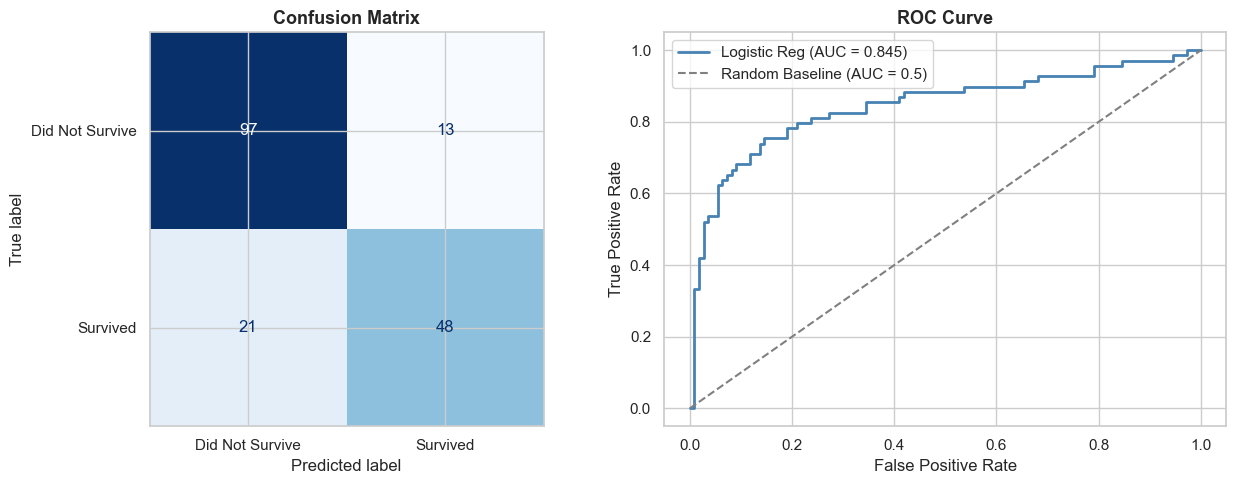

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Did Not Survive", "Survived"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix", fontsize=13, fontweight="bold")

# ── ROC Curve ─────────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color="steelblue", linewidth=2, label=f"Logistic Reg (AUC = {auc:.3f})")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Baseline (AUC = 0.5)")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve", fontsize=13, fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.show()

### Reading the Confusion Matrix

```
                     Predicted
                  No        Yes
Actual  No   [ True Neg  | False Pos ]   ← predicted survived, but didn't
        Yes  [ False Neg | True Pos  ]   ← predicted didn't survive, but did
```

**False Negatives** (bottom-left): We predicted someone didn't survive, but they did. In a real rescue scenario, these are the people we would have stopped looking for.

**False Positives** (top-right): We predicted someone survived, but they didn't. We would have wasted rescue resources.

## 1.6 — Interpreting the Model: Coefficients

One major advantage of logistic regression is **interpretability**. Each feature has a coefficient that tells us its direction and relative importance.

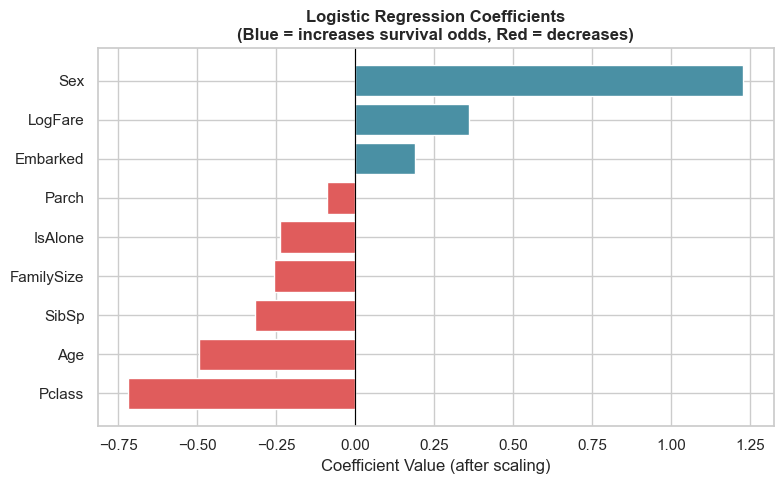

   Feature  Coefficient
    Pclass    -0.718338
       Age    -0.496109
     SibSp    -0.316808
FamilySize    -0.258049
   IsAlone    -0.239580
     Parch    -0.088300
  Embarked     0.190026
   LogFare     0.360853
       Sex     1.228540


In [11]:
coef_df = pd.DataFrame({
    "Feature": FEATURES,
    "Coefficient": log_reg.coef_[0]
}).sort_values("Coefficient")

colors = ["#e05c5c" if c < 0 else "#4a90a4" for c in coef_df["Coefficient"]]

plt.figure(figsize=(8, 5))
plt.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Logistic Regression Coefficients\n(Blue = increases survival odds, Red = decreases)",
          fontsize=12, fontweight="bold")
plt.xlabel("Coefficient Value (after scaling)")
plt.tight_layout()
plt.show()

print(coef_df.to_string(index=False))

### Activity 2 — Reading the Coefficients

Look at the coefficient chart and answer:

1. Which feature has the **strongest positive** effect on predicted survival? Does this match your EDA hypothesis from Lesson 2?
2. Which feature has the **strongest negative** effect? What does that mean in plain English?
3. `IsAlone` and `FamilySize` are both in the model and are related. What do you notice about their coefficients? Is there a potential problem here?
4. A passenger's `Pclass` coefficient is negative. What does that mean — does being in a higher-numbered class (3rd class) help or hurt survival odds according to the model?

In [ ]:
# Your answers here

# 1.

# 2.

# 3.

# 4.

## 1.7 — Cross-Validation: Is Our Score Trustworthy?

A single train/test split can be lucky or unlucky depending on which 20% ended up in the test set. **Cross-validation** gives us a more stable estimate.

In [ ]:
# Scale the full feature matrix for cross-validation
X_scaled = scaler.fit_transform(X)

cv_scores = cross_val_score(log_reg, X_scaled, y, cv=5, scoring="accuracy")

print("5-Fold Cross-Validation Accuracy:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.3f}")
print(f"\n  Mean:  {cv_scores.mean():.3f}")
print(f"  Std:   {cv_scores.std():.3f}")
print()
print("A low std (< 0.02) means the model is stable across different data splits.")

## Part 1 Summary

| | Score |
|---|---|
| Naive Baseline Accuracy | ~0.616 |
| Logistic Regression Accuracy | ~0.810 |
| ROC-AUC | ~0.86 |
| 5-Fold CV Mean Accuracy | ~0.80 |

**Takeaways:**
- Logistic regression meaningfully beats the naive baseline
- The model confirms our EDA hypotheses: `Sex` and `Pclass` are the strongest drivers
- The model is interpretable — we can explain *why* it makes each prediction
- In Lessons 4 and 5, we will use this as the bar to beat with Random Forest and XGBoost

---
# Part 2 — Linear Regression on House Prices
## Regression: Predicting a Continuous Number

**Business question:** Given features of a house, what will it sell for?

**Target:** `SalePrice` — a continuous dollar amount (e.g. $150,000, $340,000)

This is a **regression** problem. The output is a number on a continuous scale — not a category.

### Why Linear Regression?
- Assumes the target is a **weighted sum** of input features
- Coefficients are directly readable: "Each additional square foot adds $X to the price"
- The simplest possible regression model — an essential baseline before trying complex models

```
  SalePrice = b0 + b1*GrLivArea + b2*OverallQual + b3*GarageCars + ...
                ↑                   ↑                  ↑
           intercept           coefficient        coefficient
           (base price)        (per sq ft)       (per garage space)
```

### Why Not Logistic Regression Here?
Logistic regression outputs a **probability between 0 and 1** — it is designed for categories. If we used it to predict house prices, it would try to squeeze $350,000 into a 0–1 range. That doesn't make sense. **Different output types require different model families.**

## 2.1 — Load the Dataset

```bash
# Download from Kaggle (requires API token configured)
kaggle competitions download -c house-prices-advanced-regression-techniques
unzip house-prices-advanced-regression-techniques.zip
```

We will use `train.csv` from the competition.

In [ ]:
houses = pd.read_csv("train.csv")  # from the Kaggle competition zip

print("Shape:", houses.shape)
print("\nTarget — SalePrice:")
print(houses["SalePrice"].describe().apply(lambda x: f"${x:,.0f}"))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(houses["SalePrice"], bins=50, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("SalePrice Distribution (Original)")
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))

sns.histplot(np.log1p(houses["SalePrice"]), bins=50, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("SalePrice Distribution (Log Transformed)")

plt.suptitle("House Sale Price — Before and After Log Transform", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Original skew:          {houses['SalePrice'].skew():.3f}")
print(f"Log-transformed skew:   {np.log1p(houses['SalePrice']).skew():.3f}")
print()
print("Linear regression assumes the target is roughly normally distributed.")
print("High skew violates that assumption — log transform fixes it.")

## 2.2 — Data Preparation

The House Prices dataset has 79 features. We will build a **focused baseline** using a small set of the most intuitive numeric features, which is a standard industry practice when starting out.

In [ ]:
# Select intuitive numeric features for baseline
HOUSE_FEATURES = [
    "GrLivArea",      # Above-ground living area (sq ft)
    "OverallQual",    # Overall material and finish quality (1-10)
    "GarageCars",     # Garage capacity (number of cars)
    "TotalBsmtSF",    # Total basement area (sq ft)
    "FullBath",       # Full bathrooms above grade
    "YearBuilt",      # Original construction year
    "TotRmsAbvGrd",   # Total rooms above grade
]

houses_clean = houses[HOUSE_FEATURES + ["SalePrice"]].dropna()

# Log-transform the target
houses_clean["LogSalePrice"] = np.log1p(houses_clean["SalePrice"])

print(f"Rows after dropping any missing: {len(houses_clean)}")
houses_clean[HOUSE_FEATURES].describe().round(1)

In [ ]:
# Quick correlation check — which features relate most to price?
corr_with_price = houses_clean[HOUSE_FEATURES + ["SalePrice"]].corr()["SalePrice"].drop("SalePrice").sort_values(ascending=False)

plt.figure(figsize=(7, 4))
colors = ["#4a90a4" if c > 0 else "#e05c5c" for c in corr_with_price]
plt.barh(corr_with_price.index, corr_with_price.values, color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Correlation of Each Feature with SalePrice", fontsize=12, fontweight="bold")
plt.xlabel("Pearson Correlation")
plt.tight_layout()
plt.show()

### Activity 3 — Before We Train

Look at the correlation chart and discuss:

1. Which feature is most correlated with SalePrice? Does that make intuitive sense?
2. We are predicting `LogSalePrice` instead of `SalePrice`. After the model predicts a log price, how do we convert it back to a real dollar amount to show a home buyer? (Hint: think about what the inverse of `log1p` is)
3. We deliberately left out categorical features like `Neighborhood` and `HouseStyle`. What would we need to do to include them?

In [ ]:
# Your answers here

# 1.

# 2. How to convert log prediction back to dollars:
# predicted_log_price = model.predict(X_new)
# predicted_price = ???

# 3.

## 2.3 — Naive Baseline and Train

In [ ]:
X_h = houses_clean[HOUSE_FEATURES]
y_h = houses_clean["LogSalePrice"]

X_h_train, X_h_test, y_h_train, y_h_test = train_test_split(
    X_h, y_h, test_size=0.2, random_state=42
)

# ── Naive Baseline: always predict the mean ────────────────────────────────────
# For regression, the naive baseline is predict-the-mean.
# Any model that can't beat this hasn't learned anything useful.
mean_log_price = y_h_train.mean()
naive_preds_h  = np.full(len(y_h_test), mean_log_price)

naive_rmse = np.sqrt(mean_squared_error(y_h_test, naive_preds_h))
naive_rmse_dollars = np.expm1(mean_log_price + naive_rmse) - np.expm1(mean_log_price)

print(f"Naive baseline (predict mean log price):")
print(f"  RMSE (log scale):  {naive_rmse:.4f}")
print(f"  Approximate error in dollars: ${naive_rmse_dollars:,.0f}")

# ── Train Linear Regression ───────────────────────────────────────────────────
scaler_h = StandardScaler()
X_h_train_scaled = scaler_h.fit_transform(X_h_train)
X_h_test_scaled  = scaler_h.transform(X_h_test)

lin_reg = LinearRegression()
lin_reg.fit(X_h_train_scaled, y_h_train)

print("\nLinear regression trained.")

## 2.4 — Evaluation

For regression, we use different metrics than classification — there are no classes to be right or wrong about. We measure **how far off** our predictions are.

In [ ]:
y_h_pred = lin_reg.predict(X_h_test_scaled)

rmse = np.sqrt(mean_squared_error(y_h_test, y_h_pred))
mae  = mean_absolute_error(y_h_test, y_h_pred)
r2   = r2_score(y_h_test, y_h_pred)

# Convert RMSE back to dollar scale for interpretability
# This is approximate — gives a rough sense of dollar error magnitude
rmse_dollars = np.expm1(rmse) - 1

print("=" * 50)
print(f"  Naive Baseline RMSE (log): {naive_rmse:.4f}")
print(f"  Linear Regression RMSE  : {rmse:.4f}  ({'-' if rmse < naive_rmse else '+'}{ abs(rmse - naive_rmse):.4f} vs baseline)")
print()
print(f"  MAE  (log scale): {mae:.4f}")
print(f"  R²   Score:       {r2:.3f}")
print("=" * 50)
print()
print("R² interpretation:")
print(f"  {r2:.3f} means the model explains {r2*100:.1f}% of the variance in house prices")
print("  R² of 1.0 = perfect. R² of 0.0 = as good as predicting the mean (our baseline).")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Actual vs Predicted ───────────────────────────────────────────────────────
axes[0].scatter(y_h_test, y_h_pred, alpha=0.4, color="steelblue", edgecolors="white", linewidth=0.3)
min_val, max_val = y_h_test.min(), y_h_test.max()
axes[0].plot([min_val, max_val], [min_val, max_val], color="red", linewidth=1.5, linestyle="--", label="Perfect prediction")
axes[0].set_xlabel("Actual Log SalePrice")
axes[0].set_ylabel("Predicted Log SalePrice")
axes[0].set_title("Actual vs Predicted", fontsize=12, fontweight="bold")
axes[0].legend()

# ── Residuals ─────────────────────────────────────────────────────────────────
residuals = y_h_test - y_h_pred
axes[1].scatter(y_h_pred, residuals, alpha=0.4, color="darkorange", edgecolors="white", linewidth=0.3)
axes[1].axhline(0, color="black", linewidth=1.2, linestyle="--")
axes[1].set_xlabel("Predicted Log SalePrice")
axes[1].set_ylabel("Residual (Actual − Predicted)")
axes[1].set_title("Residual Plot", fontsize=12, fontweight="bold")

plt.suptitle("Linear Regression — Diagnostic Plots", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Reading the Diagnostic Plots

**Actual vs Predicted:** Points should cluster along the red diagonal. Points far from the line are large prediction errors.

**Residual Plot:** Residuals should be **randomly scattered around zero** with no pattern. If you see a curve or a funnel shape, it means the model is systematically wrong in some range — a sign that a linear model may not be the right choice.

> Look at the residuals for **very high-priced houses**. What pattern do you notice? What does that suggest about the limits of a linear model here?

## 2.5 — Interpreting Coefficients

In [ ]:
coef_h_df = pd.DataFrame({
    "Feature": HOUSE_FEATURES,
    "Coefficient": lin_reg.coef_
}).sort_values("Coefficient")

colors_h = ["#e05c5c" if c < 0 else "#4a90a4" for c in coef_h_df["Coefficient"]]

plt.figure(figsize=(8, 4))
plt.barh(coef_h_df["Feature"], coef_h_df["Coefficient"], color=colors_h)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Linear Regression Coefficients\n(After scaling — larger bar = stronger influence on log price)",
          fontsize=12, fontweight="bold")
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.show()

print(coef_h_df.to_string(index=False))
print(f"\nIntercept: {lin_reg.intercept_:.4f}")

### Activity 4 — Coefficients and Business Meaning

Remember: we are predicting **log(SalePrice)**, and all features are **scaled**. So coefficients represent relative influence, not raw dollar amounts.

1. Which feature has the largest positive coefficient? Is this the same as the feature with the highest correlation from the chart in 2.2?
2. `YearBuilt` has a positive coefficient. What does this mean in plain English — does an older or newer house sell for more?
3. We only used 7 features out of 79 available. What is the **risk** of adding too many features to a linear regression? What is the **risk** of using too few?
4. This model predicts log price. A buyer asks: *"How much will this house sell for?"* Write the one line of Python that converts a model prediction back to dollars.

In [ ]:
# Activity 4 answers

# 1.

# 2.

# 3.

# 4. Convert one prediction to dollars:
sample = X_h_test_scaled[0:1]
log_price_prediction = lin_reg.predict(sample)[0]
dollar_prediction = ???   # fill this in
print(f"Predicted price: ${dollar_prediction:,.0f}")

---
# Lesson Recap — Classification vs. Regression

| | Logistic Regression | Linear Regression |
|---|---|---|
| **Problem type** | Classification | Regression |
| **Output** | Probability → class label | Continuous number |
| **Dataset** | Titanic | House Prices |
| **Naive baseline** | Predict majority class | Predict mean price |
| **Key metrics** | Accuracy, Precision, Recall, AUC | RMSE, MAE, R² |
| **Interpretability** | Coefficients → log-odds of class | Coefficients → change in target per feature |

### The Golden Rule
> **The output type determines the model family.**  
> A category → Classification. A number on a continuous scale → Regression.

### What's Coming in Lessons 4 and 5

Our logistic regression hit ~81% accuracy. Our linear regression explained ~80% of price variance. These are solid baselines — but they make strong assumptions:

- Linear regression assumes a **straight-line** relationship between features and target
- Logistic regression assumes features combine **additively** without interactions

In Lesson 4 we will break these assumptions on purpose with **Random Forest** and **XGBoost**, which can capture non-linear patterns and feature interactions automatically. In Lesson 5 we explore **Neural Networks**.

The question we will keep asking: **"Did the extra complexity actually help?"**

---
# Bonus — Make a Prediction for a Real Passenger

Now that the model is trained, let's use it to predict survival for a specific passenger profile.

In [ ]:
# Define a passenger — change these values and re-run!
new_passenger = pd.DataFrame([{
    "Pclass":     3,       # 3rd class
    "Sex":        0,       # 0 = male, 1 = female
    "Age":        22,
    "SibSp":      1,
    "Parch":      0,
    "LogFare":    np.log1p(7.25),
    "Embarked":   0,       # 0 = Southampton
    "FamilySize": 2,       # SibSp + Parch + 1
    "IsAlone":    0,
}])

new_scaled = scaler.transform(new_passenger)
survival_prob = log_reg.predict_proba(new_scaled)[0][1]
prediction    = log_reg.predict(new_scaled)[0]

print(f"Predicted survival probability : {survival_prob:.1%}")
print(f"Predicted outcome              : {'Survived ✓' if prediction == 1 else 'Did Not Survive ✗'}")
print()
print("Try changing Sex to 1 (female) or Pclass to 1 and see how the probability changes.")